## **Preamble**

This is the location of the code that will extract radar columns from around the location of the
UND research citation jet during the MC3E field campaign. This code will probably not work many times
and then eventually work when I don't think it will... 

In [3]:
# Libraries
import pyart
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.feature as cfeature
import xarray as xr
import os
import imageio.v2 as imageio
import pandas as pd
import time

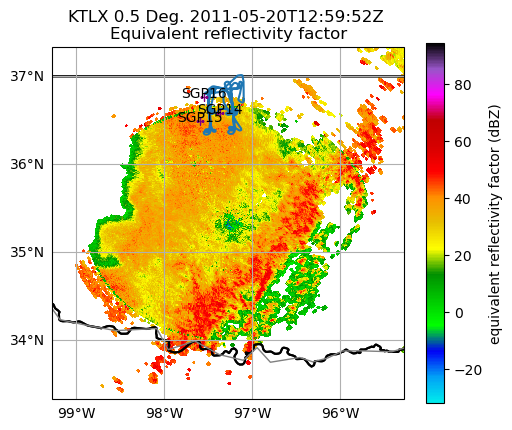

In [24]:
# Flight track over radar data plot
citation_nav = pd.read_csv('2011-05-20_CITATION.dat', sep = ',', header = None)
cit_lat = citation_nav.iloc[:, 2]
cit_lon = citation_nav.iloc[:, 3]

# Reflectivity plotting 
filename = 'KTLX20110520_125935_V03.gz'
data = pyart.io.read('KTLX_May_20_2011/' + filename)

display = pyart.graph.RadarMapDisplay(data)

projection = ccrs.PlateCarree()

center_lon = data.longitude['data'][0]
center_lat = data.latitude['data'][0]

data.latitude['data'][0] = center_lat
data.longitude['data'][0] = center_lon

# Establish min and max latitude and longitude to be plotted:
min_lat = center_lat - 2 #subtracting 1.5 degrees lat
max_lat = center_lat + 2 #adding 1.5 degrees lat
min_lon = center_lon - 2 #subtracting 1.5 degrees lon
max_lon = center_lon + 2 #adding 1.5 degrees lon

fig = plt.figure(figsize = (11,9))

ax = fig.add_axes([0.06, 0.50, 0.40, 0.40], projection = projection)
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')

a = display.plot_ppi_map('reflectivity', 
                            ax = ax,
                            sweep = 1, 
                            cmap = 'NWSRef', 
                            min_lon = min_lon, 
                            max_lon = max_lon,
                            min_lat = min_lat,
                            max_lat = max_lat)

plt.plot(cit_lon, cit_lat)
#SGP16
plt.annotate('SGP16', xy = (-97.5472, 36.7675),ha = 'center')
plt.plot(-97.5472, 36.7675, marker = '+', color = 'purple')
#SGP15
plt.annotate('SGP15', (-97.593889, 36.49111), ha = 'center')
plt.plot(-97.593889, 36.49111, marker = '+', color = 'purple')
#SGP14
plt.annotate('SGP14', (-97.363611, 36.578611), ha = 'center')
plt.plot(-97.363611, 36.578611, marker = '+', color = 'purple')
plt.show()
#\u2708 is the airplane latex code

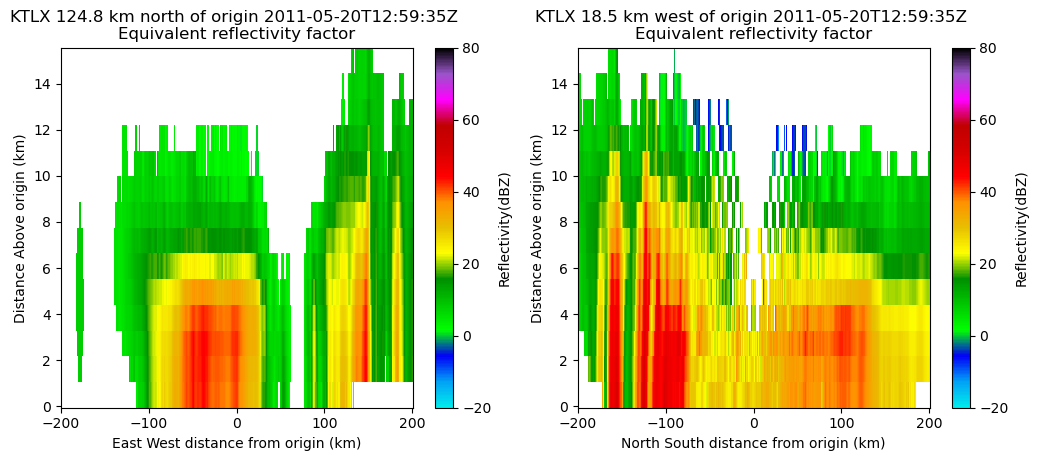

In [55]:
filename = 'KTLX20110520_125935_V03.gz'
data = pyart.io.read('KTLX_May_20_2011/' + filename)

# Convert file to cartesian coordinates

# Define grid limits 
z_grid_limits = (500., 15000.)
y_grid_limits = (-200000.,200000.)
x_grid_limits = (-200000.,200000.)

grid_resolution = 1000

def compute_number_of_points(extent, resolution):
    return int((extent[1] - extent[0])/resolution)

z_grid_points = compute_number_of_points(z_grid_limits, grid_resolution)
x_grid_points = compute_number_of_points(x_grid_limits, grid_resolution)
y_grid_points = compute_number_of_points(y_grid_limits, grid_resolution)

grid = pyart.map.grid_from_radars(data,
                                  grid_shape=(z_grid_points,
                                              y_grid_points,
                                              x_grid_points),
                                  grid_limits=(z_grid_limits,
                                               y_grid_limits,
                                               x_grid_limits),
                                 )

fig = plt.figure(figsize = (11,9))
display = pyart.graph.GridMapDisplay(grid)
time_step = 150
# Horizontal reflectivity
ax = fig.add_axes([0.53, 0.50, 0.40, 0.40])
display.plot_longitude_slice('reflectivity',
                  ax = ax,
                  lon=cit_lon[time_step],
                  vmin=-20,
                  vmax=80,
                  cmap='NWSRef')


# Vertical cross section reflectivity
ax1 = fig.add_axes([0.06, 0.50, 0.40, 0.40])
display.plot_latitude_slice('reflectivity',
                            ax = ax1,
                            lat=cit_lat[time_step],
                            vmin=-20,
                            vmax=80,
                            cmap='NWSRef')

plt.savefig('Cross_Section_Radar2.png')

### Old attempt at trying to create a code that would create a vertical cross section of radar data using the column extract method and code. 

col1 = pyart.util.columnsect.get_field_location(data, 35.5, -97.5)
col2 = pyart.util.columnsect.get_field_location(data, 36.5, -97.5)
col3 = pyart.util.columnsect.get_field_location(data, 37.5, -97.5)
vscan = xr.concat([col1, col2, col3], dim = 'height')
vscan.reflectivity.plot(y = 'height')
col1.attrs
 (lat/lon, height, ref)
plt.pcolormesh([lat/lon], height, ref)

vscan = (35.5, col1.reflectivity[:], col1['height'])
lat = [35.5, 36.5, 37.5]

plt.pcolormesh(0, [lat, vscan['height']], vscan.reflectivity)

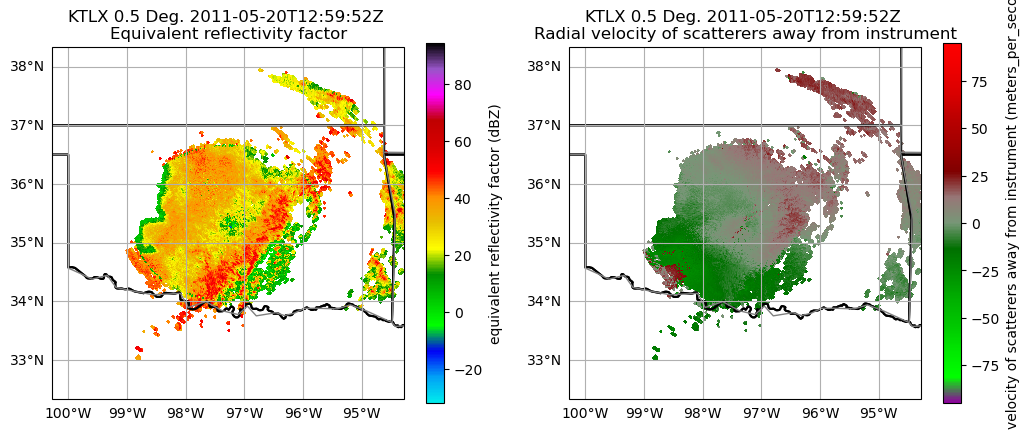

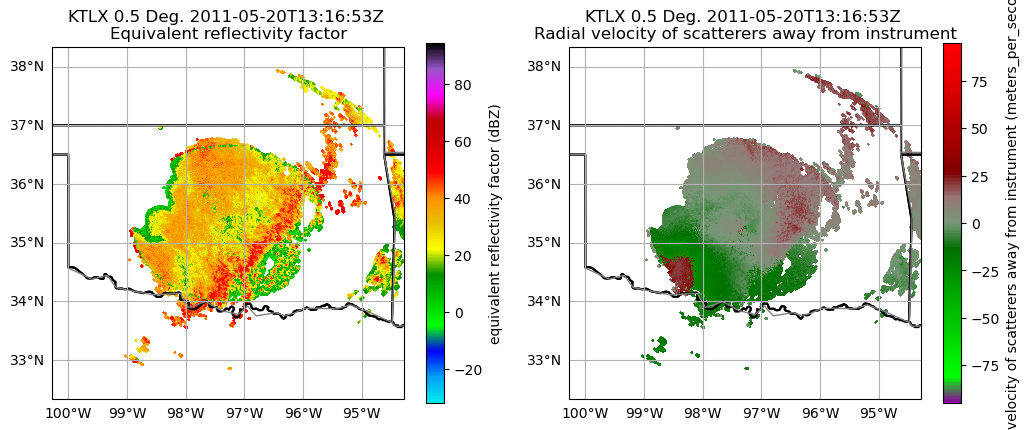

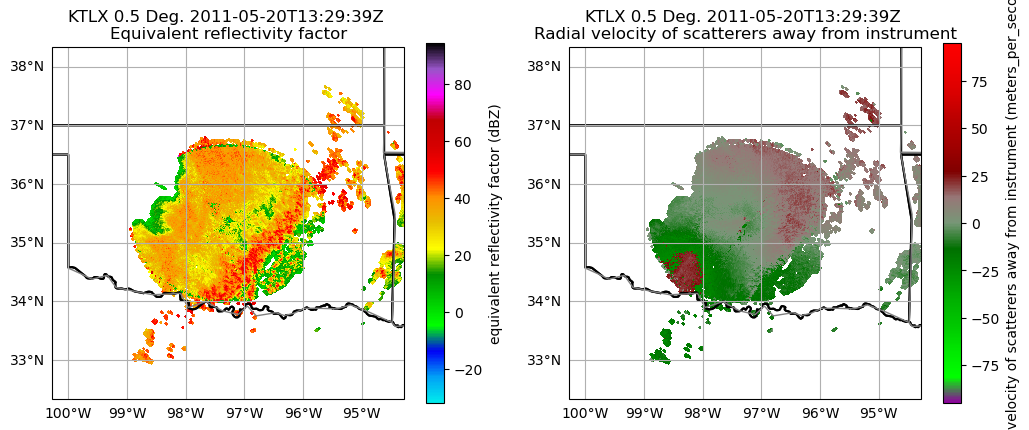

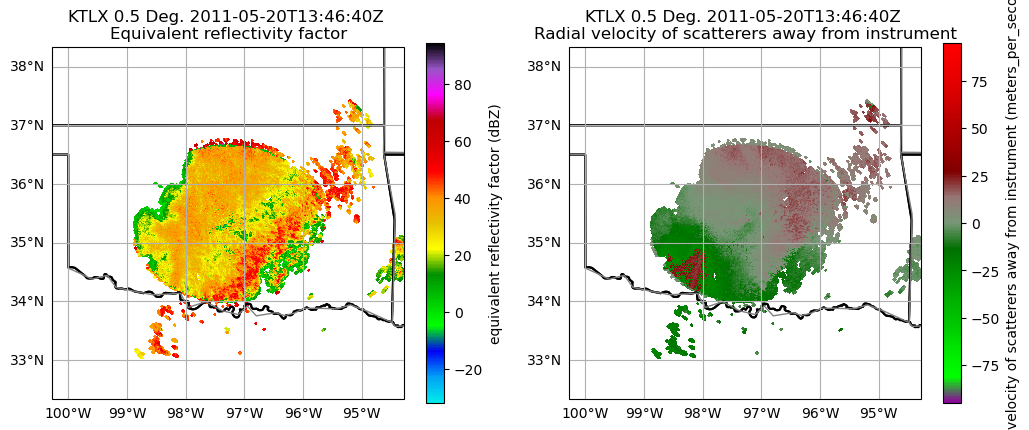

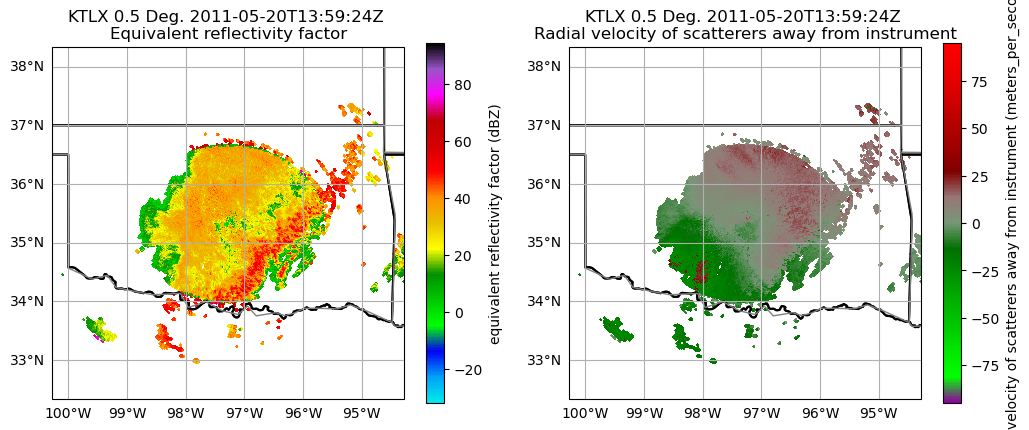

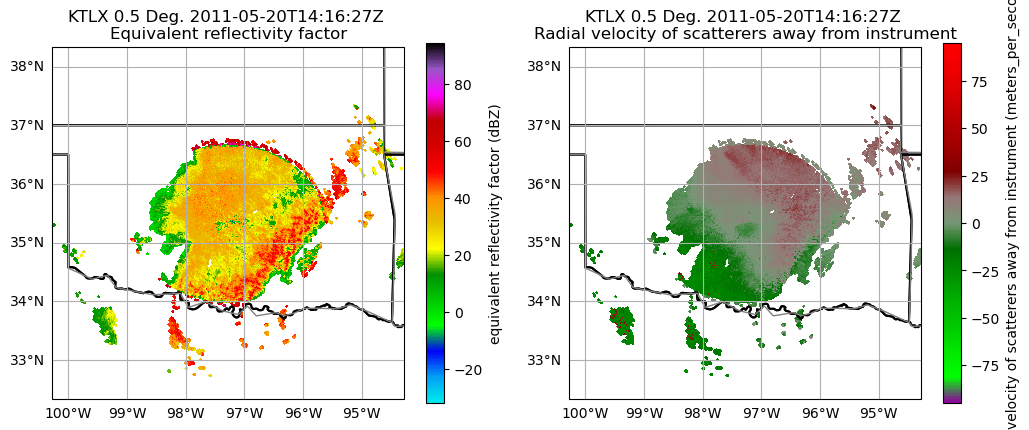

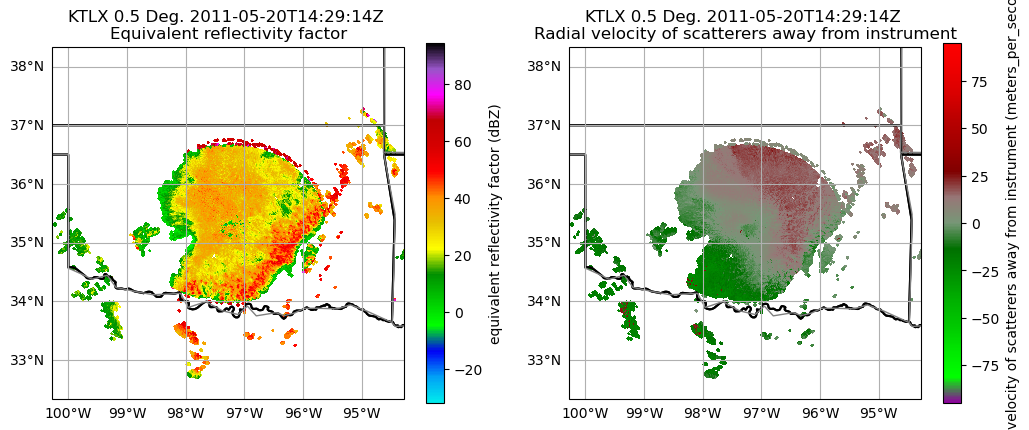

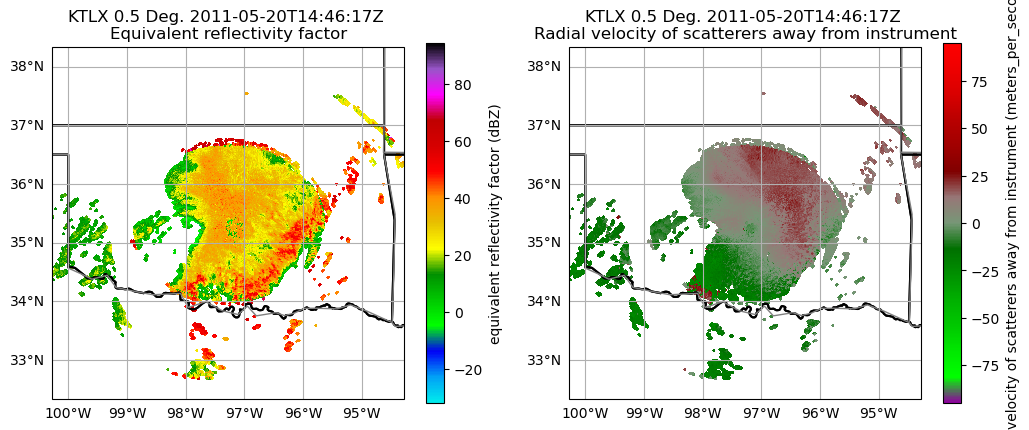

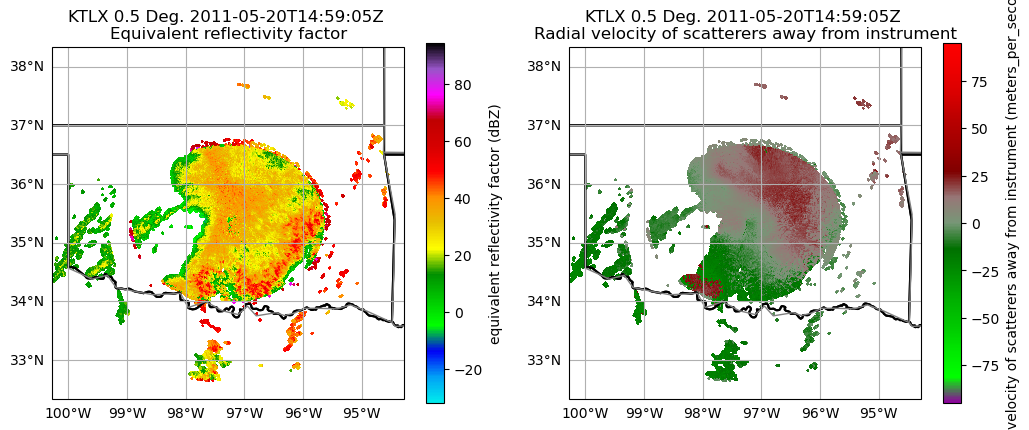

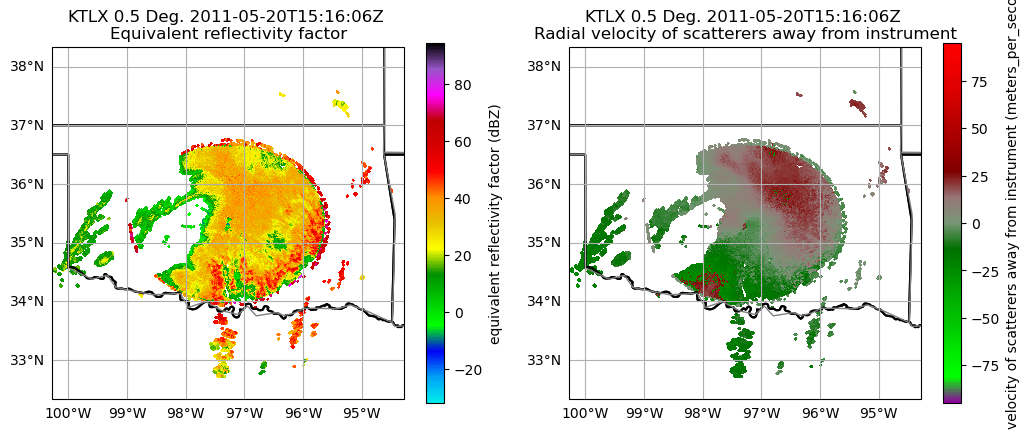

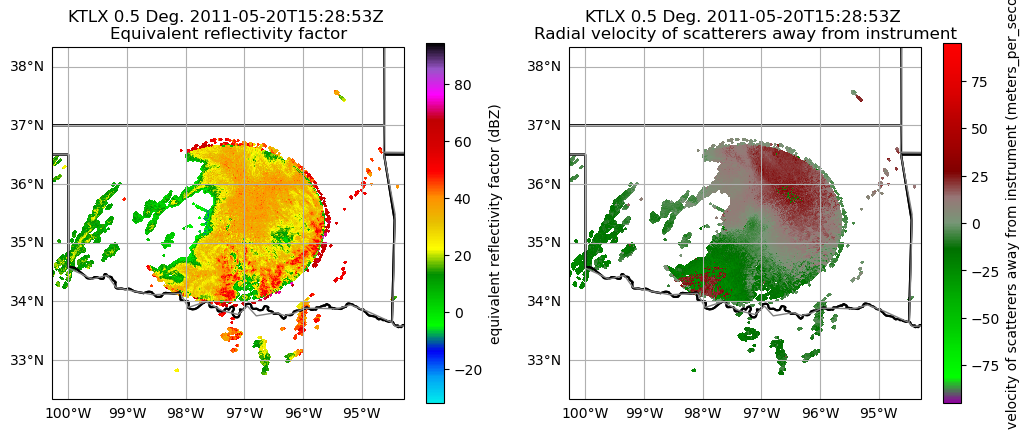

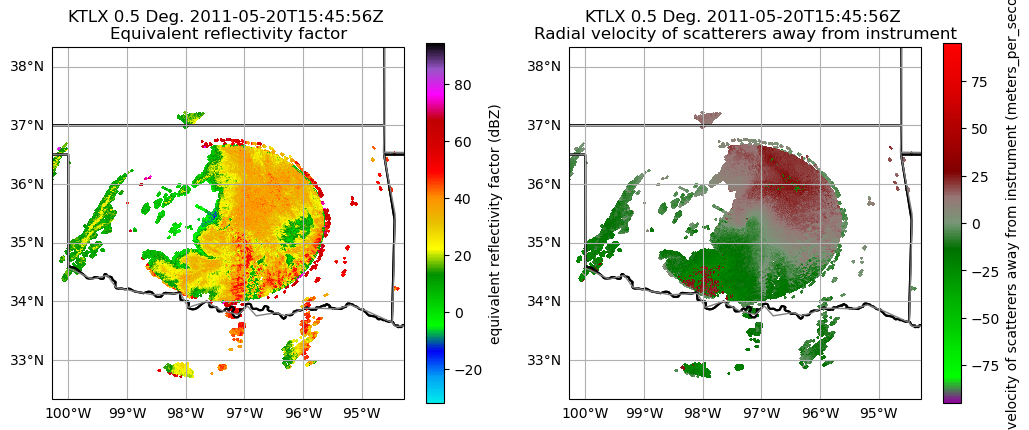

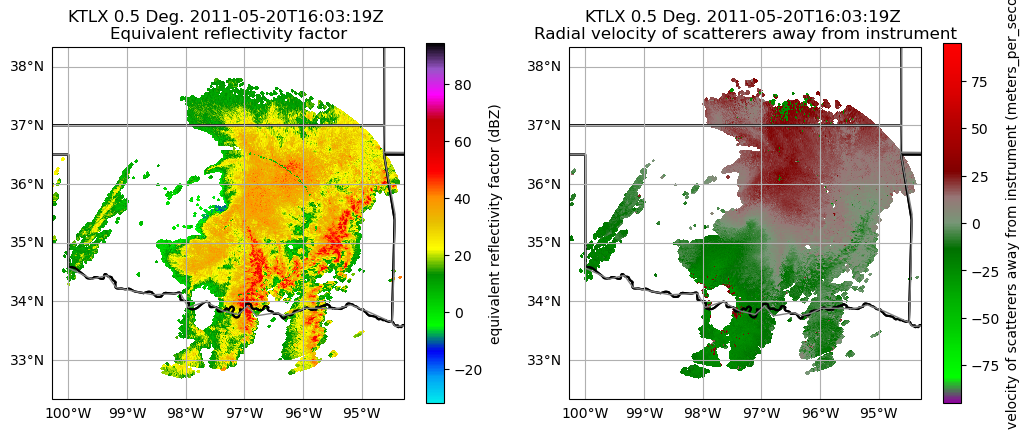

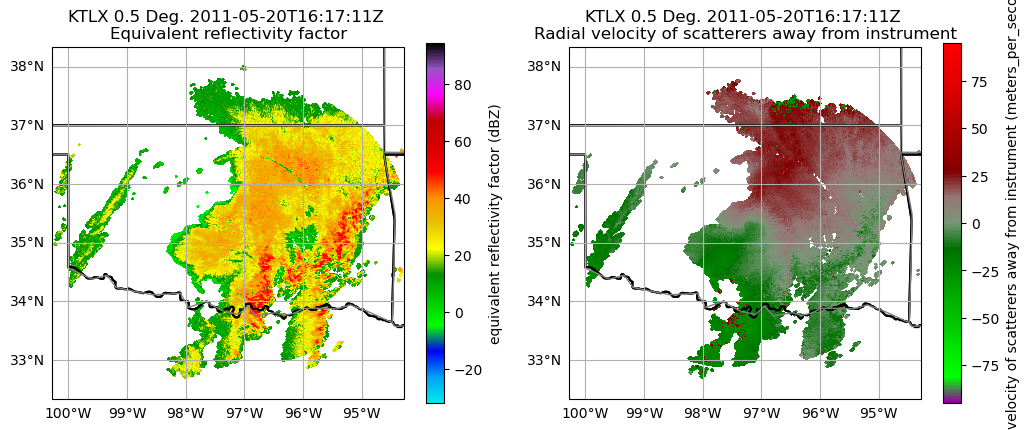

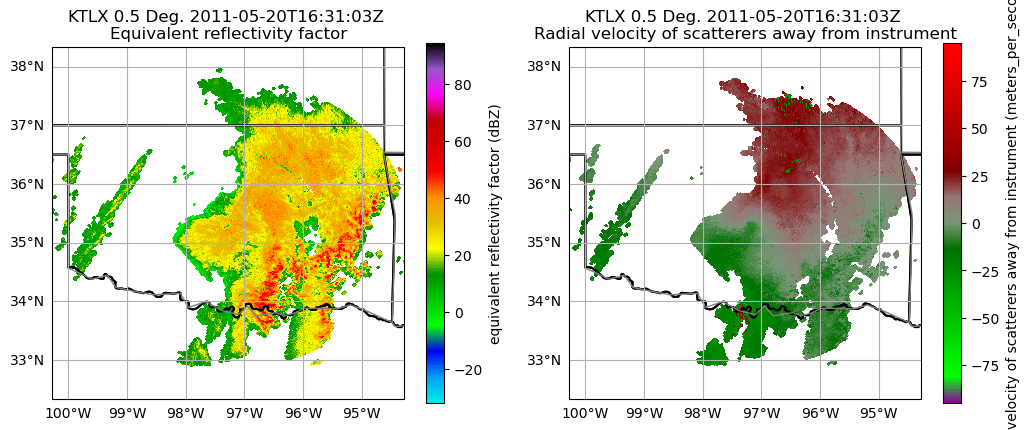

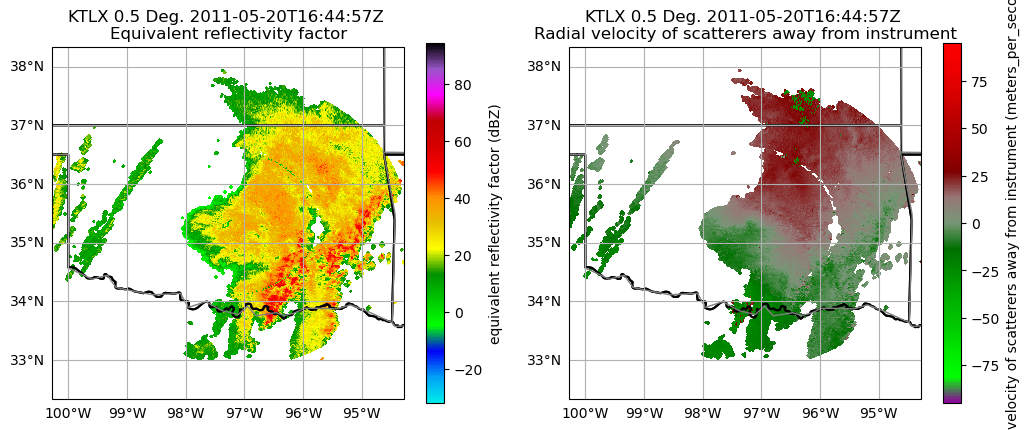

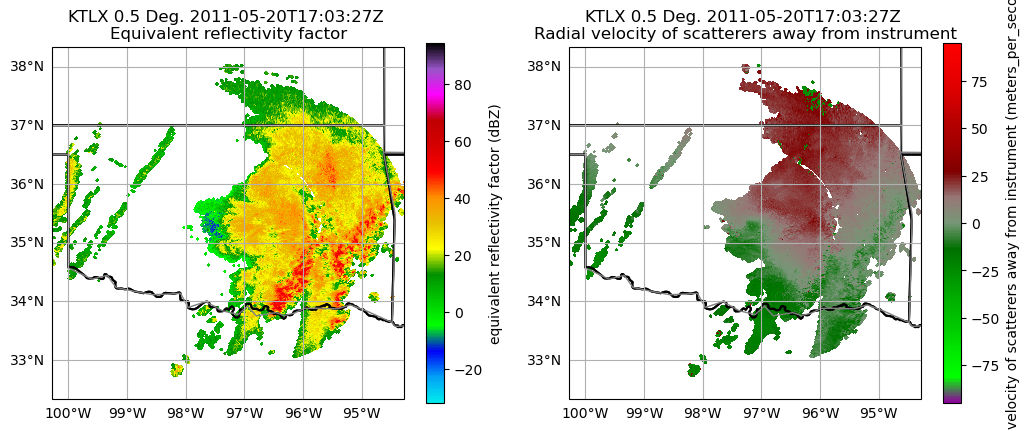

In [45]:
with os.scandir('KTLX_May_20_2011/') as entries:
    for entry in entries:
        # Data read in 
        filename = entry.name
        data = pyart.io.read('KTLX_May_20_2011/' + filename)
        #dir(data)

        # Reflectivity plotting 
        display = pyart.graph.RadarMapDisplay(data)
        
        projection = ccrs.PlateCarree()
        
        center_lon = data.longitude['data'][0]
        center_lat = data.latitude['data'][0]
        
        # Establish min and max latitude and longitude to be plotted:
        map_offset = 3
        min_lat = center_lat - map_offset #subtracting 1.5 degrees lat
        max_lat = center_lat + map_offset #adding 1.5 degrees lat
        min_lon = center_lon - map_offset #subtracting 1.5 degrees lon
        max_lon = center_lon + map_offset #adding 1.5 degrees lon
        
        fig = plt.figure(figsize = (11,9))
        
        # Reflectivity plot
        ax = fig.add_axes([0.06, 0.50, 0.40, 0.40], projection = projection)
        ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')
        
        display.plot_ppi_map('reflectivity', 
                            ax = ax,
                            sweep = 1, 
                            cmap = 'NWSRef', 
                            min_lon = min_lon, 
                            max_lon = max_lon,
                            min_lat = min_lat,
                            max_lat = max_lat) #Variable name
        
        # Velocity plot
        ax1 = fig.add_axes([0.53, 0.50, 0.40, 0.40], projection = projection)
        ax1.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')
        
        display.plot_ppi_map('velocity', 
                            ax = ax1, 
                            sweep = 1, 
                            cmap = 'NWSVel', 
                            min_lon = min_lon, 
                            max_lon = max_lon,
                            min_lat = min_lat,
                            max_lat = max_lat)
        
        '''
        Reference table for different changable variables 
        
                             sweep = 0, #Elevation angle
                             vmin = -20, #Min value
                             vmax = 80, #Max value
                             min_lon = min_lon, #Min longitude of plot
                             max_lon = max_lon, #Max longitude of plot
                             min_lat = min_lat, #Min latitude of plot
                             max_lat = max_lat, #Max latitude of plot
                             resolution = '10m', #Projection resolution
                             projection = projection, #Set projection
                             colorbar_flag = 0, #Turn off colorbar; will add manually
                             title_flag = 0, #Turn off title; will add manually
                             ax = ax, # Display axis set
                             fig = fig, #Where to plot data
                             embellish = False, #Turn off default map outlines
                             lat_0 = center_lat, #Center latitude
                             lon_0 = center_lon, #Center longitude
                             cmap = 'NWSRef' #Color scheme for colorbar
                             
        '''
        
        # Code to add aircraft marker to represent location of aircraft during in-situ measurements 
        #arcft_pos = (-97.5, 36.5)
        #ax.annotate('\u2708', xy = arcft_pos, fontsize = 12, rotation = 90)
        #ax1.annotate('\u2708', xy = arcft_pos, fontsize = 12, rotation = 90)

        plt.ioff()
        plt.savefig(filename + '.png')
        plt.tight_layout()

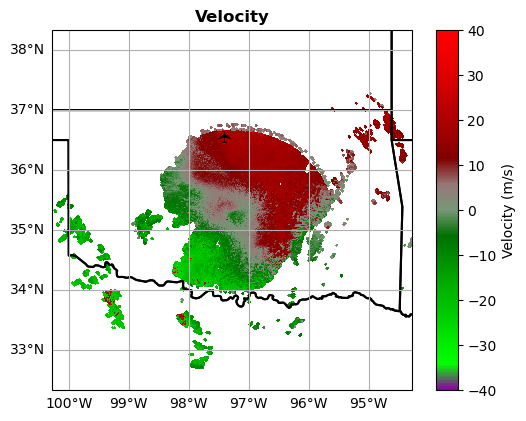

In [113]:
# Velocity plotting 
display = pyart.graph.RadarMapDisplay(data)

projection = ccrs.PlateCarree()

center_lon = data.longitude['data'][0]
center_lat = data.latitude['data'][0]

data.latitude['data'][0] = center_lat
data.longitude['data'][0] = center_lon

# Establish min and max latitude and longitude to be plotted:
min_lat = center_lat - 3 #subtracting 1.5 degrees lat
max_lat = center_lat + 3 #adding 1.5 degrees lat
min_lon = center_lon - 3 #subtracting 1.5 degrees lon
max_lon = center_lon + 3 #adding 1.5 degrees lon

fig = plt.figure(figsize = (11,9))

ax = fig.add_axes([0.06, 0.50, 0.40, 0.40], projection = projection)
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')

a = display.plot_ppi_map('velocity', #Variable name
                     sweep = 1, #Elevation angle
                     vmin = -40, #Min value
                     vmax = 40, #Max value
                     min_lon = min_lon, #Min longitude of plot
                     max_lon = max_lon, #Max longitude of plot
                     min_lat = min_lat, #Min latitude of plot
                     max_lat = max_lat, #Max latitude of plot
                     resolution = '10m', #Projection resolution
                     projection = projection, #Set projection
                     colorbar_flag = 0, #Turn off colorbar; will add manually
                     title_flag = 0, #Turn off title; will add manually
                     ax = ax,
                     fig = fig, #Where to plot data
                     embellish = False, #Turn off default map outlines
                     lat_0 = center_lat, #Center latitude
                     lon_0 = center_lon, #Center longitude
                     cmap = 'NWSVel' #Color scheme for colorbar
                     )

cax = fig.add_axes([.445, .50, .02, .40])
display.plot_colorbar(a, cax = cax, orient='vertical', label='Velocity (m/s)')

ax.set_title('Velocity', fontweight = 'bold')

ax.annotate('\u2708', xy = (-97.5, 36.5), fontsize = 12, rotation = 90)

plt.tight_layout()

In [7]:
with imageio.get_writer('storm-animation.gif', mode='I', loop = 0, duration = 500) as writer:
    with os.scandir('May_20_2011_Radar_Pics/') as entries:
        for photo in entries:
            image = imageio.imread('May_20_2011_Radar_Pics/' + photo.name)
            writer.append_data(image)